## Code

This code demonstrates the process of building, training and evaluating a neural network model using TensorFlow and Keras to classify handwritten digits from the MNIST dataset.

The model architecture is defined using the **Sequential API** consisting of:

- Flatten layer to convert the 2D image input into a 1D array
- Dense layer with 128 neurons and ReLU activation
- a final Dense layer with 10 neurons and softmax activation to output probabilities for each digit class.

Model is compiled with the Adam optimizer, SparseCategoricalCrossentropy loss function and SparseCategoricalAccuracy metric and then trained for 5 epochs on the training data.

In [1]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import SparseCategoricalCrossentropy
from tensorflow.keras.metrics import SparseCategoricalAccuracy

In [2]:
# Load and prepare the MNIST dataset
mnist = tf.keras.datasets.mnist

(x_train, y_train), (x_test, y_test) = mnist.load_data()

x_train, x_test = x_train / 255.0, x_test / 255.0

In [3]:
# Build the model
model = Sequential([
    tf.keras.Input(shape=(28, 28)),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
])

# Compile the model
model.compile(optimizer=Adam(),
              loss=SparseCategoricalCrossentropy(),
              metrics=[SparseCategoricalAccuracy()])

# Train the model
model.fit(x_train, y_train, epochs=5)

# Evaluate the model
test_loss, test_acc = model.evaluate(x_test, y_test)
print(f'\nTest accuracy: {test_acc}')

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 0.4300 - sparse_categorical_accuracy: 0.8774
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 0.1218 - sparse_categorical_accuracy: 0.9643
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 0.0795 - sparse_categorical_accuracy: 0.9764
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 0.0546 - sparse_categorical_accuracy: 0.9837
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 0.0438 - sparse_categorical_accuracy: 0.9870
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0807 - sparse_categorical_accuracy: 0.9760  

Test accuracy: 0.9787999987602234


## Theory

[Article](https://www.geeksforgeeks.org/nlp/feedforward-neural-network/)  

Feedforward Neural Network (FNN) is a type of artificial neural network in which information flows in a single direction—from the input layer through hidden layers to the output layer—*without loops or feedback*. It is mainly used for pattern recognition tasks like image and speech classification.
```
For example in a credit scoring system banks use an FNN which analyze users' financial profiles—such as income, credit history and spending habits—to determine their creditworthiness. Each piece of information flows through the network’s layers where various calculations are made to produce a final score.
```

**Structure of a Feedforward Neural Network**

Feedforward Neural Networks have a structured layered design where data flows sequentially through each layer.

1. **Input Layer**: The input layer consists of neurons that receive the input data. Each neuron in the input layer represents a feature of the input data.
2. **Hidden Layers**: One or more hidden layers are placed between the input and output layers. These layers are responsible for learning the complex patterns in the data. Each neuron in a hidden layer applies a weighted sum of inputs followed by a non-linear activation function.
2. **Output Layer**: The output layer provides the final output of the network. The number of neurons in this layer corresponds to the number of classes in a classification problem or the number of outputs in a regression problem.

Each connection between neurons in these layers has an associated weight that is adjusted during the training process to minimize the error in predictions.

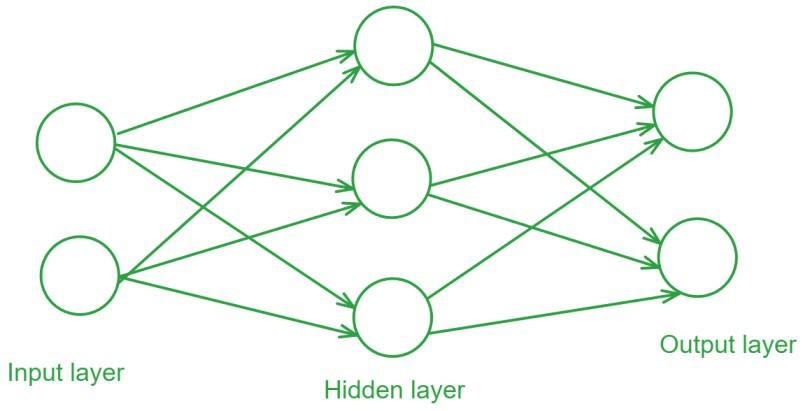

### Activation Functions

Activation functions introduce non-linearity into the network, enabling it to learn and model complex data patterns.

Common activation functions include:

- **Sigmoid**:  
  $$\sigma(x) = \frac{1}{1 + e^{-x}}$$

- **Tanh**:  
  $$\tanh(x) = \frac{e^x - e^{-x}}{e^x + e^{-x}}$$

- **ReLU**:  
  $$\text{ReLU}(x) = \max(0, x)$$


### Training a Feedforward Neural Network

Training a Feedforward Neural Network involves adjusting the weights of the neurons to minimize the error between the predicted output and the actual output. This process is typically performed using backpropagation and gradient descent.

1. **Forward Propagation**: During forward propagation the input data passes through the network and the output is calculated.
2. **Loss Calculation**: The loss (or error) is calculated using a loss function such as Mean Squared Error (MSE) for regression tasks or Cross-Entropy Loss for classification tasks.
3. **Backpropagation**: In backpropagation the error is propagated back through the network to update the weights. The gradient of the loss function with respect to each weight is calculated and the weights are adjusted using gradient descent.

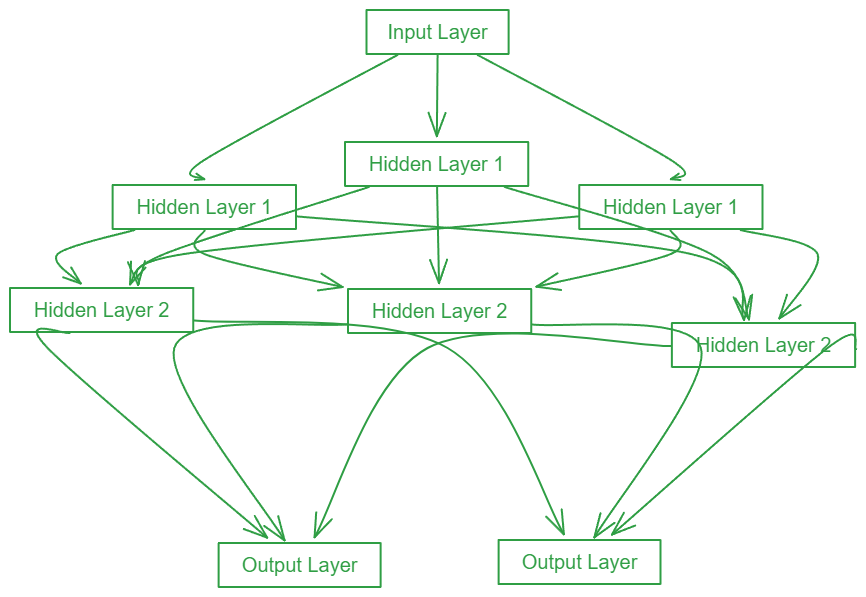

### Gradient Descent

Gradient Descent is an optimization algorithm used to minimize the loss function by iteratively updating the weights in the direction of the negative gradient. Common variants of gradient descent include:

- **Batch Gradient Descent**: Updates weights after computing the gradient over the entire dataset.
- **Stochastic Gradient Descent (SGD)**: Updates weights for each training example individually.
- **Mini-batch Gradient Descent**: It Updates weights after computing the gradient over a small batch of training examples.

### Evaluation of Feedforward neural network

Evaluating the performance of the trained model involves several metrics:

- **Accuracy**: The proportion of correctly classified instances out of the total instances.
- **Precision**: The ratio of true positive predictions to the total predicted positives.
- **Recall**: The ratio of true positive predictions to the actual positives.
- **F1 Score**: The harmonic mean of precision and recall, providing a balance between the two.
- **Confusion Matrix**: A table used to describe the performance of a classification model, showing the true positives, true negatives, false positives, and false negatives.